# VLS inspection

Loads a config 2 combined H5 file and produces two views of the
Gotthard / VLS data:

1. The mean spectrum averaged over every (train, bunch) shot.
2. A 2D map of mean spectrum vs bunch index (averaged over trains).

Pixel axis is uncalibrated for now (raw Gotthard pixel index).

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import config
from data_loading import load_data

%matplotlib inline

## Parameters

In [ ]:
# Set USE_RAW_H5 = True to load the raw FLASH H5 files for RUN_NO
# instead of a pre-built combined H5. Useful during the experiment
# before write_h5.py has been run on the measurement. SDU (z) and TDC
# data are not available in raw mode, so trim/downsample/save-moments
# are disabled when USE_RAW_H5 is True.
USE_RAW_H5 = False
RUN_NO     = 54609     # only used when USE_RAW_H5 is True
MAX_FILES  = 1         # raw H5 files are large; limit how many to load

# Combined-H5 inputs (used when USE_RAW_H5 is False).
H5_FILE    = config.COMBINED_DIR / "test_config2.h5"
TRIM_START = 3
TRIM_END   = 3
DOWNSAMPLE_N = 10

# Pixel-space region of interest. Set to None for the full spectrum.
ROI = (380, 500)

# Log-stretch the 2D map; helps reveal weak features.
LOG_MAP    = False

# Save the per-shot spectral moments (sum, COM, width) back into the
# source H5 file under the `vls_moments` group, along with attributes
# describing the preprocessing (crop_roi, background_roi). Ignored
# when USE_RAW_H5 is True (raw dir is read-only).
SAVE_MOMENTS = False

## Load and inspect

In [ ]:
if USE_RAW_H5:
    from data_loading import load_raw_h5
    data = load_raw_h5(RUN_NO, config=2, max_files=MAX_FILES)
    source_label = f"raw run {RUN_NO}"
else:
    data = load_data(str(H5_FILE), config=2,
                     trim_start=TRIM_START, trim_end=TRIM_END,
                     downsample_N=DOWNSAMPLE_N)
    source_label = str(H5_FILE)

print(f"source            : {source_label}")
print(f"vls raw shape     : {data.vls.shape}")
print(f"vls dtype         : {data.vls.dtype}")

if ROI is not None:
    data = data.crop_vls(*ROI)
    print(f"cropping to ROI   : pixels {ROI[0]} .. {ROI[1]}")

In [4]:
data = data.auto_subtract_background((60,100))    

# pixel_ax is data.vls_pixels — source-pixel indices for plot x-axes
n_trains, n_bunches, n_pixels = data.vls.shape
print(f"vls shape         : {data.vls.shape}")
print(f"trains × bunches  : {n_trains} × {n_bunches} = {n_trains * n_bunches} shots")
print(f"pixels per spectrum: {n_pixels}")
print(f"value min / max   : {np.nanmin(data.vls):.1f} / {np.nanmax(data.vls):.1f}")
print(f"mean per shot     : {np.nanmean(data.vls):.1f}")

vls shape         : (883, 100, 120)
trains × bunches  : 883 × 100 = 88300 shots
pixels per spectrum: 120
value min / max   : -238.8 / 10575.4
mean per shot     : 223.1


## Average spectrum (over every shot)

Mean of the VLS over both the train and bunch axes — one spectrum that
represents the full dataset. The shaded band is ±1 std of that mean,
so a flat band over a sharp peak suggests the peak is very stable.

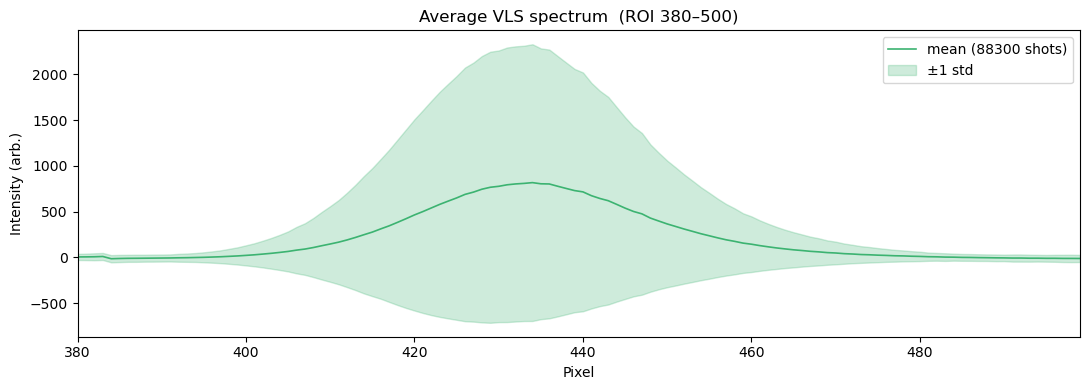

In [5]:
pixel_ax = data.vls_pixels
flat = data.vls.reshape(-1, n_pixels)         # (n_trains * n_bunches, n_pixels)
mean_spec = np.nanmean(flat, axis=0)
std_spec  = np.nanstd(flat,  axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pixel_ax, mean_spec, color="mediumseagreen", lw=1.2,
        label=f"mean ({flat.shape[0]} shots)")
ax.fill_between(pixel_ax, mean_spec - std_spec, mean_spec + std_spec,
                color="mediumseagreen", alpha=0.25, label="±1 std")
ax.set_xlabel("Pixel")
ax.set_ylabel("Intensity (arb.)")
ax.set_title("Average VLS spectrum"
             + (f"  (ROI {ROI[0]}–{ROI[1]})" if ROI is not None else ""))
ax.set_xlim(pixel_ax[0], pixel_ax[-1])
ax.legend()
fig.tight_layout()
plt.show()

## Mean spectrum vs bunch index

Mean over trains only, keeping the bunch axis. Each row of the 2D map
is one bunch's average spectrum, so vertical stripes mean a feature is
common to every bunch.

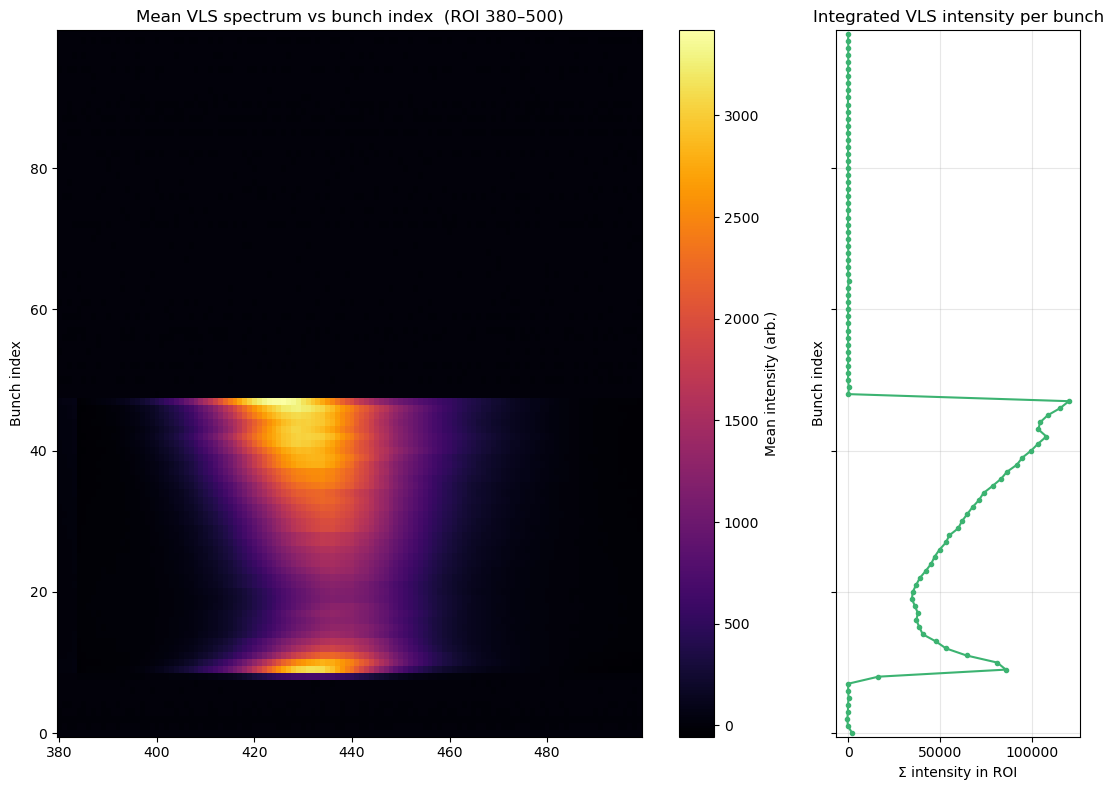

In [6]:
mean_by_bunch = np.nanmean(data.vls, axis=0)   # (n_bunches, n_pixels)

fig, axes = plt.subplots(
    1, 2, figsize=(11, 8),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)

# --- 2D map ----------------------------------------------------------
ax = axes[0]
norm = mcolors.LogNorm(vmin=max(np.nanmin(mean_by_bunch), 1e-3),
                       vmax=np.nanmax(mean_by_bunch)) if LOG_MAP else None
im = ax.pcolormesh(pixel_ax, np.arange(n_bunches), mean_by_bunch,
                   cmap="inferno", shading="auto", norm=norm)
fig.colorbar(im, ax=ax, label="Mean intensity (arb.)")
ax.set_ylabel("Bunch index")
ax.set_title("Mean VLS spectrum vs bunch index"
             + (f"  (ROI {ROI[0]}–{ROI[1]})" if ROI is not None else ""))

# --- Bunch-integrated intensity --------------------------------------
ax = axes[1]
total_per_bunch = np.nansum(mean_by_bunch, axis=1)
ax.plot(total_per_bunch, np.arange(n_bunches),
        marker="o", ms=3, color="mediumseagreen")
ax.set_xlabel("Σ intensity in ROI")
ax.set_ylabel("Bunch index")
ax.set_title("Integrated VLS intensity per bunch")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Mean spectrum vs train index

Mean over bunches only, keeping the train axis. Each row of the 2D map
is one train's average spectrum.

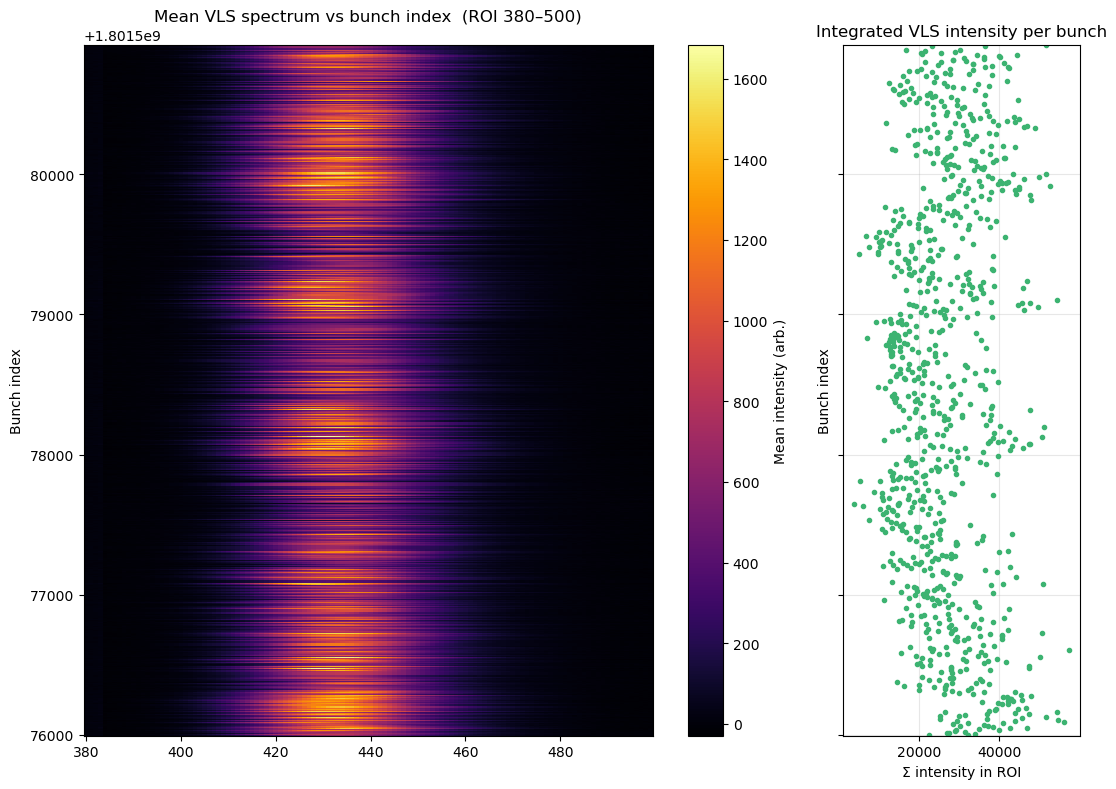

In [7]:
mean_by_train = np.nanmean(data.vls, axis=1)   # (n_bunches, n_pixels)

fig, axes = plt.subplots(
    1, 2, figsize=(11, 8),
    gridspec_kw={"width_ratios": [3, 1]}, sharey=True,
)

# --- 2D map ----------------------------------------------------------
ax = axes[0]
norm = mcolors.LogNorm(vmin=max(np.nanmin(mean_by_train), 1e-3),
                       vmax=np.nanmax(mean_by_train)) if LOG_MAP else None
im = ax.pcolormesh(pixel_ax, data.tID, mean_by_train,
                   cmap="inferno", shading="auto", norm=norm)
fig.colorbar(im, ax=ax, label="Mean intensity (arb.)")
ax.set_ylabel("Bunch index")
ax.set_title("Mean VLS spectrum vs bunch index"
             + (f"  (ROI {ROI[0]}–{ROI[1]})" if ROI is not None else ""))

# --- Bunch-integrated intensity --------------------------------------
ax = axes[1]
total_per_bunch = np.nansum(mean_by_train, axis=1)
ax.plot(total_per_bunch, data.tID,
        marker="o", ms=3, color="mediumseagreen",
        ls='',)
ax.set_xlabel("Σ intensity in ROI")
ax.set_ylabel("Bunch index")
ax.set_title("Integrated VLS intensity per bunch")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Per-shot spectral moments

Sum, centre-of-mass, and width (sqrt of the second central moment) for
every (train, bunch) shot, computed on the **current** VLS state
(i.e. after cropping and background subtraction). COM and width are
in source-pixel units. Background-subtracted spectra with near-zero
nets give very noisy COMs / widths — see the long tails in the
histograms.

sums shape    : (883, 100)
sums range    : -12534.5 .. 273450.5
coms range    : -17676.49 .. 22855.70
widths range  : 0.05 .. 22671.29
crop_roi      : (380, 500)
background_roi: (60, 100)


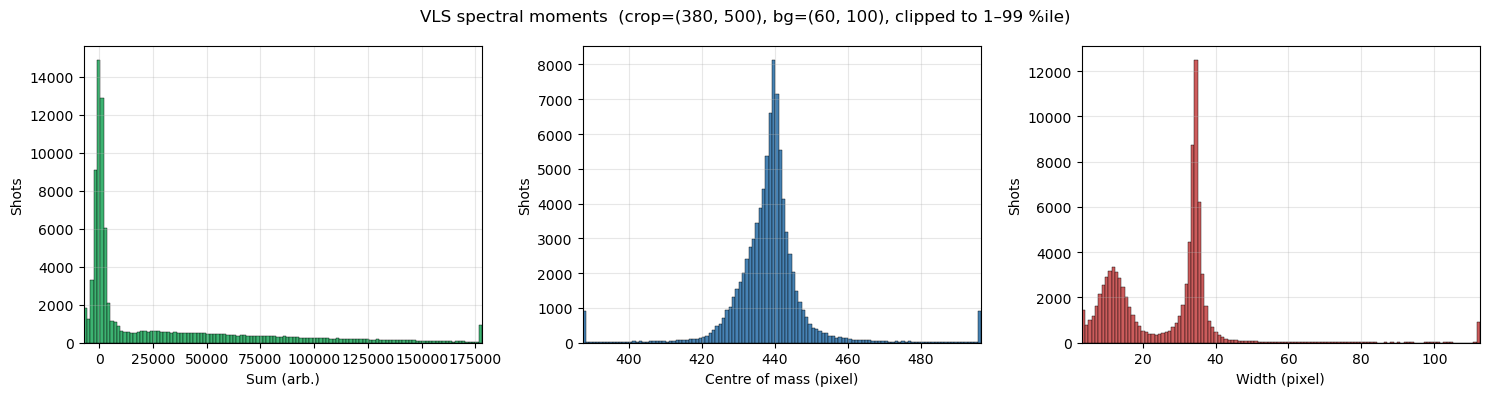

In [8]:
data = data.compute_vls_moments()

print(f"sums shape    : {data.vls_sums.shape}")
print(f"sums range    : {np.nanmin(data.vls_sums):.1f} .. {np.nanmax(data.vls_sums):.1f}")
print(f"coms range    : {np.nanmin(data.vls_coms):.2f} .. {np.nanmax(data.vls_coms):.2f}")
print(f"widths range  : {np.nanmin(data.vls_widths):.2f} .. {np.nanmax(data.vls_widths):.2f}")
print(f"crop_roi      : {data.vls_crop_roi}")
print(f"background_roi: {data.vls_background_roi}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, label, color in zip(
    axes,
    [data.vls_sums, data.vls_coms, data.vls_widths],
    ["Sum (arb.)", "Centre of mass (pixel)", "Width (pixel)"],
    ["mediumseagreen", "steelblue", "indianred"],
):
    flat = vals.ravel()
    finite = flat[np.isfinite(flat)]
    # Robust 1–99% range so a handful of noise blow-ups don't dominate.
    lo, hi = np.nanpercentile(finite, [1, 99])
    ax.hist(np.clip(finite, lo, hi), bins=120,
            color=color, edgecolor="black", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Shots")
    ax.set_xlim(lo, hi)
    ax.grid(alpha=0.3)
fig.suptitle(
    f"VLS spectral moments  "
    f"(crop={data.vls_crop_roi}, bg={data.vls_background_roi}, "
    f"clipped to 1–99 %ile)"
)
fig.tight_layout()
plt.show()

## Persist moments to the source H5

Flip `SAVE_MOMENTS = True` in the params cell and re-run this cell to
write `vls_sums`, `vls_coms`, `vls_widths` (scattered onto the file's
full train axis with NaN for filtered trains) and the
`crop_roi` / `background_roi` attributes back into the loaded H5 file
under the `vls_moments` group. `load_data` will pick them up
automatically on subsequent runs and print the preprocessing metadata.

In [ ]:
if USE_RAW_H5:
    print("USE_RAW_H5 is True — raw H5 dir is read-only, skipping save.")
elif SAVE_MOMENTS:
    from data_loading import save_vls_moments
    save_vls_moments(data, str(H5_FILE), overwrite=True)
    print(f"saved vls_moments to {H5_FILE}")
else:
    print("SAVE_MOMENTS is False — nothing written. "
          "Set it True in the params cell to persist.")

## GMD vs per-shot VLS intensity

Uses the per-shot `vls_sums` (integrated intensity after crop and
background subtraction) as the y variable and the GMD as x. The
left axis is a 2D histogram of every shot; the right axis is the
GMD-binned mean using percentile bins (equal-count per bin), with
the OLS linear fit overlaid for direct comparison.

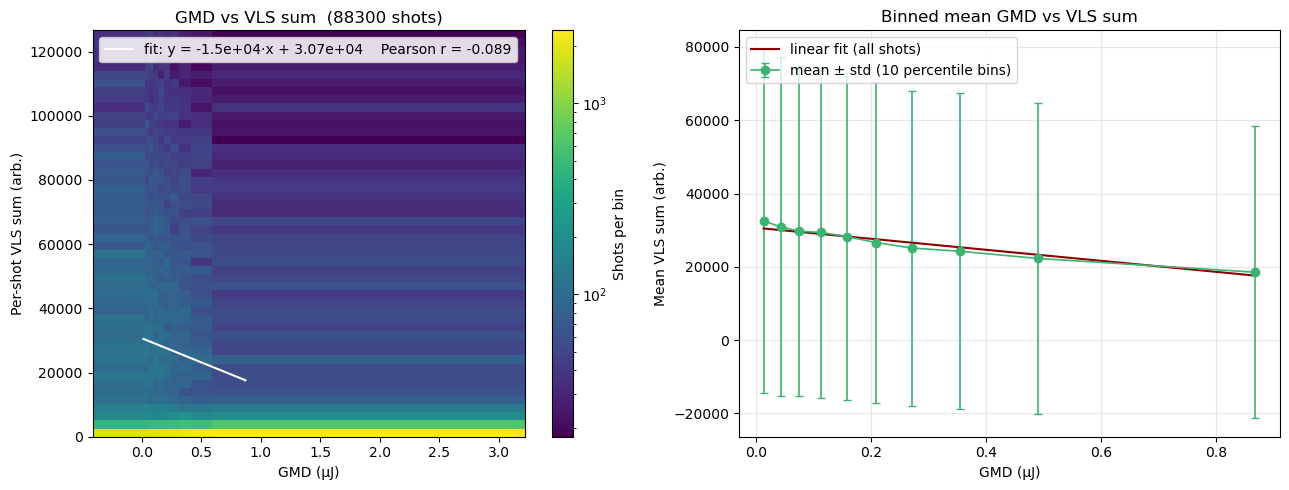

In [10]:
from binning import arb_bool_ar, bin_and_average

gmd_flat = data.gmd.ravel()
vls_flat = data.vls_sums.ravel()
good = np.isfinite(gmd_flat) & np.isfinite(vls_flat)
x = gmd_flat[good]
y = vls_flat[good]

# Percentile-based GMD edges (equal-count bins).
N_GMD_BINS = 10
gmd_edges = np.percentile(x, np.linspace(0, 100, N_GMD_BINS + 1))
gmd_cents, bool_ar = arb_bool_ar(gmd_edges, x)
mean_vls, std_vls, n_per_bin = bin_and_average(bool_ar, y)
mean_gmd, _, _              = bin_and_average(bool_ar, x)

r = float(np.corrcoef(x, y)[0, 1])
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(mean_gmd.min(), mean_gmd.max(), 100)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- left: hist2d of every shot --------------------------------------
h = ax.hist2d(x, y, bins=[gmd_edges, np.linspace(0, np.percentile(y, 95), 51)], cmap="viridis", cmin=1, norm=mcolors.LogNorm())
fig.colorbar(h[3], ax=ax, label="Shots per bin")
ax.plot(x_line, slope * x_line + intercept, color="white", lw=1.5,
        label=f"fit: y = {slope:.3g}·x + {intercept:.3g}    Pearson r = {r:.3f}")
ax.set_xlabel("GMD (µJ)")
ax.set_ylabel("Per-shot VLS sum (arb.)")
ax.set_title(f"GMD vs VLS sum  ({x.size} shots)")
ax.legend(loc="upper left", framealpha=0.85)

# --- right: binned mean ± std -----------------------------------
ax2.errorbar(mean_gmd, mean_vls, yerr=std_vls,
             fmt="o-", color="mediumseagreen", capsize=3, lw=1.2,
             label=f"mean ± std ({N_GMD_BINS} percentile bins)")
ax2.plot(x_line, slope * x_line + intercept, color="darkred", lw=1.5,
         label="linear fit (all shots)")
ax2.set_xlabel("GMD (µJ)")
ax2.set_ylabel("Mean VLS sum (arb.)")
ax2.set_title("Binned mean GMD vs VLS sum")
ax2.legend(loc="upper left")
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Average VLS spectrum per GMD bin

Same percentile GMD bins as above. For each bin, average every
shot's spectrum and plot one line per bin coloured by the bin's
mean GMD. Quick way to see whether the spectrum *shape* changes
with pulse energy or only the amplitude does.

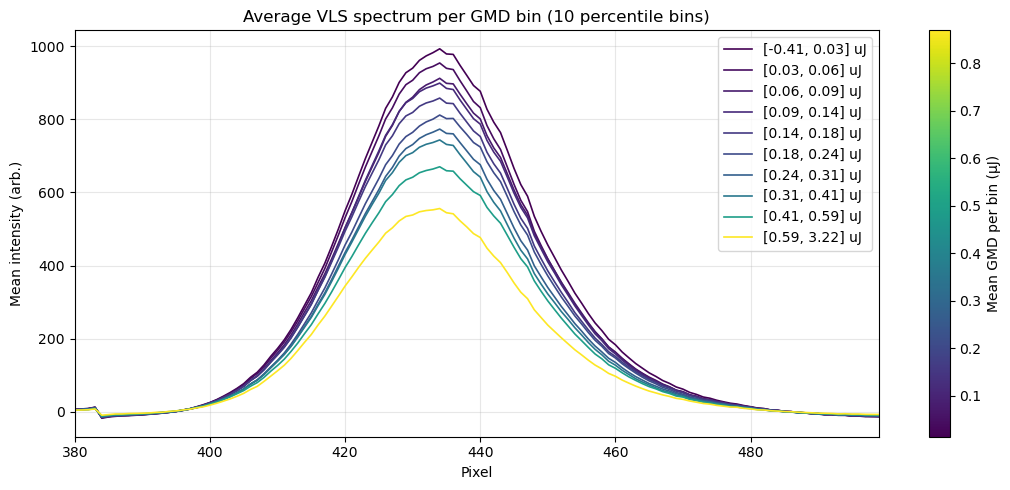

In [11]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
legend = ['[{:.2f}, {:.2f}] uJ'.format(g1, g2) for g1, g2 in zip(gmd_edges[:-1], gmd_edges[1:])]

# Per-shot spectra, flattened over the (train, bunch) axes, with the
# same `good` mask used above so the shot order matches `bool_ar`.
vls_flat_spec = data.vls.reshape(-1, data.vls.shape[-1])[good]
mean_spec_by_gmd, std_spec_by_gmd, _ = bin_and_average(bool_ar, vls_flat_spec)

pixel_ax = data.vls_pixels
n_gmd_bins = len(mean_gmd)
norm = Normalize(vmin=float(mean_gmd[0]), vmax=float(mean_gmd[-1]))
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(11, 5))
for cent, spec in zip(mean_gmd, mean_spec_by_gmd):
    ax.plot(pixel_ax, spec, color=cmap(norm(cent)), lw=1.2)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean GMD per bin (µJ)")
ax.set_xlabel("Pixel")
ax.set_ylabel("Mean intensity (arb.)")
ax.set_title(f"Average VLS spectrum per GMD bin ({n_gmd_bins} percentile bins)")
ax.set_xlim(pixel_ax[0], pixel_ax[-1])
ax.grid(alpha=0.3)
ax.legend(legend)
fig.tight_layout()
plt.show()

## Average VLS spectrum per COM bin

Same idea as the GMD-binned plot, but bin shots by their per-shot
centre of mass (`vls_coms`). Percentile bins so each line is the
average of an equal number of shots. If the spectrum has a single
moving peak, the lines will shift across the pixel axis as you
move through the colorbar; broader / multi-peak spectra will
change shape too.

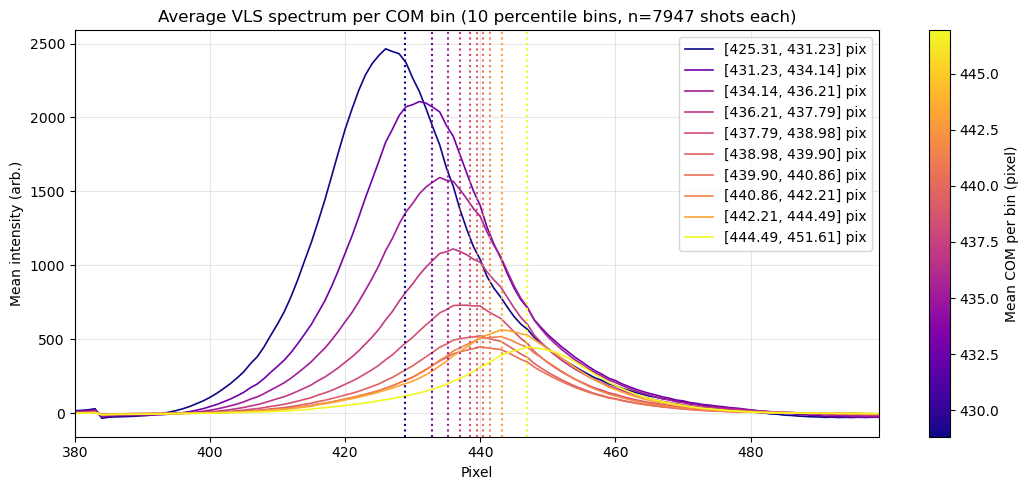

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

com_flat = data.vls_coms.ravel()
good_com = np.isfinite(com_flat)
x_com = com_flat[good_com]

# Percentile-based COM edges (equal-count bins).
N_COM_BINS = 10
com_edges = np.percentile(x_com, np.linspace(5, 95, N_COM_BINS + 1))
com_cents, bool_ar_com = arb_bool_ar(com_edges, x_com)
mean_com, _, n_per_com_bin = bin_and_average(bool_ar_com, x_com)


legend = ['[{:.2f}, {:.2f}] pix'.format(g1, g2) for g1, g2 in zip(com_edges[:-1], com_edges[1:])]

vls_flat_spec_com = data.vls.reshape(-1, data.vls.shape[-1])[good_com]
mean_spec_by_com, _, _ = bin_and_average(bool_ar_com, vls_flat_spec_com)

pixel_ax = data.vls_pixels
norm = Normalize(vmin=float(mean_com[0]), vmax=float(mean_com[-1]))
cmap = plt.cm.plasma

fig, ax = plt.subplots(figsize=(11, 5))
for cent, spec in zip(mean_com, mean_spec_by_com):
    ax.plot(pixel_ax, spec, color=cmap(norm(cent)), lw=1.2)
for cent in mean_com:
    ax.axvline(cent, color=cmap(norm(cent)), lw=1.5, alpha=1, ls=":")
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Mean COM per bin (pixel)")
ax.set_xlabel("Pixel")
ax.set_ylabel("Mean intensity (arb.)")
ax.set_title(f"Average VLS spectrum per COM bin ({N_COM_BINS} percentile bins, n={n_per_com_bin[0]} shots each)")
ax.set_xlim(pixel_ax[0], pixel_ax[-1])
ax.grid(alpha=0.3)
ax.legend(legend)
fig.tight_layout()
plt.show()